In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
import math

periodic_table = pd.read_csv("../periodic_table_dataset.csv")
real_atomic_number = periodic_table['Atomic Number'].values

df_8b = pd.read_csv("../Results/intevention/first_number_10_experiments.csv", index_col=0)
df_8b.head()

,H,He,Li,Be,B,C,N,O,F,Ne,...,Nb,Mo,Tc,Ru,Rh,Pd,Ag,Cd,In,Sn
1,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,...,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,12.0
2,17.0,17.0,NaN,NaN,17.0,17.0,17.0,17.0,17.0,17.0,...,NaN,NaN,NaN,17.0,17.0,17.0,17.0,17.0,17.0,17.0
3,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,12.0,17.0,17.0
4,17.0,17.0,17.0,NaN,17.0,17.0,17.0,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,17.0,17.0,17.0
5,17.0,17.0,17.0,NaN,17.0,17.0,17.0,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0,17.0,17.0


In [2]:
EXPERIMENTS = [
    (1, "atomic_only"), (2, "cartesian_3d"), (3, "polar_3d"),
    (4, "unit_circle_3d"), (5, "unit_circle_period"), (6, "polar_with_period"),
    (7, "polar_2d"), (8, "random_control"), (9, "random_polar"), (10, "polar_3d_arabic"),
]

titles = {
    "atomic_only": "(r) - Atomic number prompt",
    "cartesian_3d": "(r, g, p) - Atomic number prompt",
    "polar_3d": "(r cos(θ), r sin(θ), r) - Atomic number prompt",
    "unit_circle_3d": "(cos(θ), sin(θ), r) - Atomic number prompt",
    "unit_circle_period": "(cos(θ), sin(θ), p) - Atomic number prompt",
    "polar_with_period": "(r cos(θ), r sin(θ), p) - Atomic number prompt",
    "polar_2d": "(r cos(θ), r sin(θ)) - Atomic number prompt",
    "random_control": "(r_random) - Atomic number prompt",
    "random_polar": "(cos(θ_random), sin(θ_random), r) - Atomic number prompt",
    "polar_3d_arabic": "(r cos(θ), r sin(θ), r) - Arabic numerals prompt",
}

In [3]:
def plot_model_results(df, real_vals, model_label, save_path):
    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(22, 9))
    axes = axes.flatten()

    for i, (exp_id, key) in enumerate(EXPERIMENTS):
        pred = pd.to_numeric(df.loc[exp_id], errors='coerce').values
        pred = np.nan_to_num(pred)
        n = min(len(pred), len(real_vals))
        pred, real = pred[:n], real_vals[:n]

        r2 = r2_score(real, pred)
        pct_within_2 = (np.sum(np.abs(pred - real) <= 2) / len(real)) * 100

        axes[i].scatter(real, pred, s=60, alpha=0.7)
        axes[i].plot([real.min(), real.max()], [real.min(), real.max()], 'r--', alpha=0.4)
        axes[i].set_title(f"#{exp_id}: {titles[key]}", fontsize=11)
        axes[i].set_xlabel("Real Atomic Number")
        axes[i].set_ylabel("Predicted Atomic Number")
        axes[i].grid(True)
        axes[i].annotate(f"R²: {r2:.3f}\nAbs. err ≤ 2: {pct_within_2:.1f}%",
                          xy=(0.95, 0.05), xycoords='axes fraction',
                          fontsize=9, ha='right', va='bottom',
                          bbox=dict(boxstyle="round,pad=0.3", edgecolor="gray", facecolor="white", alpha=0.7))

    fig.suptitle(f"Intervention Results — {model_label}", fontsize=16)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

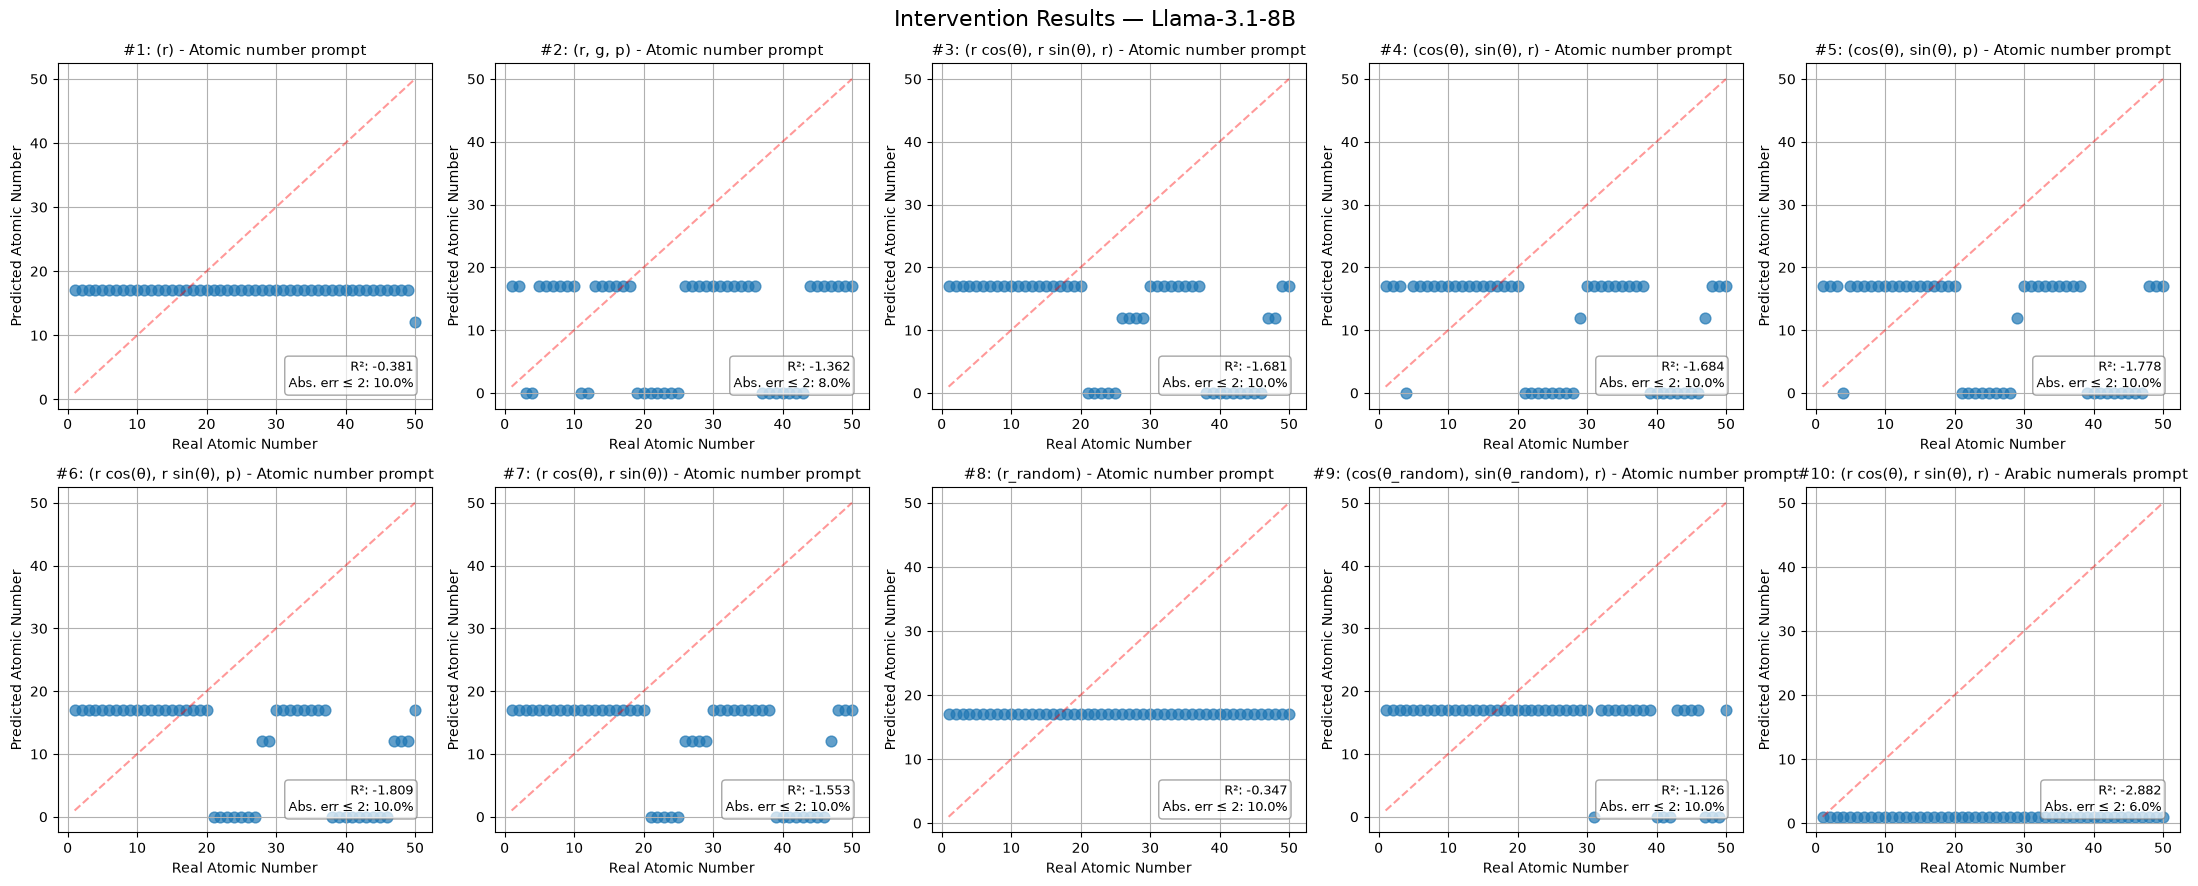

In [4]:
plot_model_results(df_8b, real_atomic_number, "Llama-3.1-8B", "../Results/intevention/error_results_8B.png")